# 23CSE301 Machine Learning — Capstone Project
## Classification Track, Part A

**Dataset:** Comprehensive Diabetes Clinical Dataset — 100,000 records, 16 columns
**Target:** `diabetes` — binary, 0 = non-diabetic, 1 = diabetic
**Task:** supervised binary classification

### Problem statement

Predict whether a patient has diabetes from routinely collected clinical and
demographic measurements: age, BMI, HbA1c, blood glucose, smoking history,
hypertension and heart disease.

### Reproducibility

`random_state = 42` is used everywhere a seed is accepted. Every transformer
that learns a parameter is fitted on the training split only.

---
# 1. Data Loading and Audit

## 1.1 Imports and configuration

One configuration cell fixes the seed, the plotting style and a colourblind-safe
palette so every figure later in the notebook is consistent.

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# one seed for the whole notebook, so every run reproduces exactly
RANDOM_STATE = 42
TEST_SIZE = 0.20
PALETTE = "colorblind"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
})

# reused whenever a plot is coloured by class
CLASS_COLOURS = {0: sns.color_palette(PALETTE)[0], 1: sns.color_palette(PALETTE)[3]}
CLASS_LABELS = {0: "Non-diabetic (0)", 1: "Diabetic (1)"}

print("pandas      ", pd.__version__)
print("numpy       ", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)
print("seaborn     ", sns.__version__)
print("\nRANDOM_STATE =", RANDOM_STATE)

pandas       3.0.6
numpy        2.5.3
scikit-learn 1.9.1
seaborn      0.13.2

RANDOM_STATE = 42


## 1.2 Load the dataset

The loader resolves any `*.csv` in `../data/` rather than hard-coding a filename,
and fails with a clear message if the file is missing.

In [2]:
DATA_DIR = os.path.join("..", "data")

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
if not csv_files:
    raise FileNotFoundError(
        f"No CSV found in {os.path.abspath(DATA_DIR)}. "
        "See data/README.md for the dataset description."
    )

DATA_PATH = csv_files[0]
df_raw = pd.read_csv(DATA_PATH)

print("File :", os.path.abspath(DATA_PATH))
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

File : /Users/renexaan/Documents/glucotrack/data/diabetes_dataset.csv
Shape: 100,000 rows x 16 columns


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


## 1.3 Structural audit

A single consolidated table is easier to read than separate `dtypes`, `isna()` and
`nunique()` calls. It reports, per column: the dtype, how many values are missing,
how many distinct values there are, and a sample of those values.

In [3]:
audit = pd.DataFrame({
    "dtype":     df_raw.dtypes.astype(str),
    "non_null":  df_raw.notna().sum(),
    "missing":   df_raw.isna().sum(),
    "missing_%": (df_raw.isna().mean() * 100).round(3),
    "n_unique":  df_raw.nunique(),
})
# a few example values make it obvious which columns are categorical vs continuous
audit["example_values"] = [
    ", ".join(map(str, df_raw[c].dropna().unique()[:4]))[:55] for c in df_raw.columns
]

print("Total missing values :", int(df_raw.isna().sum().sum()))
print("Duplicate rows       :", int(df_raw.duplicated().sum()))
audit

Total missing values : 0


Duplicate rows       : 14


,dtype,non_null,missing,missing_%,n_unique,example_values
year,int64,100000,0,0.0,7,"2020, 2015, 2016, 2019"
gender,str,100000,0,0.0,3,"Female, Male, Other"
age,float64,100000,0,0.0,102,"32.0, 29.0, 18.0, 41.0"
location,str,100000,0,0.0,55,"Alabama, Alaska, Arizona, Arkansas"
race:AfricanAmerican,int64,100000,0,0.0,2,"0, 1"
race:Asian,int64,100000,0,0.0,2,"0, 1"
race:Caucasian,int64,100000,0,0.0,2,"0, 1"
race:Hispanic,int64,100000,0,0.0,2,"0, 1"
race:Other,int64,100000,0,0.0,2,"1, 0"
hypertension,int64,100000,0,0.0,2,"0, 1"


In [4]:
# distribution of the numeric columns: range, centre and spread
df_raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
year,100000.0,2018.361,1.345,2015.00,2019.00,2019.00,2019.00,2022.00
age,100000.0,41.886,22.517,0.08,24.00,43.00,60.00,80.00
race:AfricanAmerican,100000.0,0.202,0.402,0.00,0.00,0.00,0.00,1.00
race:Asian,100000.0,0.200,0.400,0.00,0.00,0.00,0.00,1.00
race:Caucasian,100000.0,0.199,0.399,0.00,0.00,0.00,0.00,1.00
race:Hispanic,100000.0,0.199,0.399,0.00,0.00,0.00,0.00,1.00
race:Other,100000.0,0.200,0.400,0.00,0.00,0.00,0.00,1.00
hypertension,100000.0,0.075,0.263,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039,0.195,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.321,6.637,10.01,23.63,27.32,29.58,95.69


## 1.4 Target variable and class balance

Class balance determines both the metrics that are meaningful and how the
train/test split has to be performed, so it is measured before anything else.

In [5]:
TARGET = "diabetes"

counts = df_raw[TARGET].value_counts().sort_index()
pcts = df_raw[TARGET].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "class":      [CLASS_LABELS[i] for i in counts.index],
    "count":      counts.values,
    "percentage": pcts.round(2).values,
})

imbalance_ratio = counts.max() / counts.min()

print(summary.to_string(index=False))
print(f"\nMajority class  : {pcts.max():.2f}%")
print(f"Minority class  : {pcts.min():.2f}%")
print(f"Imbalance ratio : {imbalance_ratio:.2f} : 1")
print(f"\nA model predicting the majority class for every row would score "
      f"{pcts.max():.1f}% accuracy while identifying no diabetic patients.")

           class  count  percentage
Non-diabetic (0)  91500        91.5
    Diabetic (1)   8500         8.5

Majority class  : 91.50%
Minority class  : 8.50%
Imbalance ratio : 10.76 : 1

A model predicting the majority class for every row would score 91.5% accuracy while identifying no diabetic patients.


### Observation — 1

- 100,000 rows, 16 columns, and no missing values anywhere in the frame.
- 14 exact duplicate rows are present.
- Class split is 91,500 non-diabetic to 8,500 diabetic, a ratio of 10.76 to 1.
- `race` arrives already one-hot encoded across five indicator columns rather than as a single categorical column.
- `smoking_history` includes a "No Info" level, which records missingness rather than a behaviour.
- `hbA1c_level` and `blood_glucose_level` each take only 18 distinct values, and `bmi` has one value repeated far more than any other.

---
# 2. Exploratory Data Analysis

All EDA runs on the raw, unsplit frame. That is legitimate because it is purely
descriptive: nothing measured here is fed into a fitted transformer. Every
transformer that learns a parameter is fitted on the training split alone in
section 3.

## 2.1 Distribution of each numeric feature

Continuous features: ['year', 'age', 'bmi', 'hbA1c_level', 'blood_glucose_level']
Binary flags excluded: ['diabetes', 'hypertension', 'heart_disease', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other']


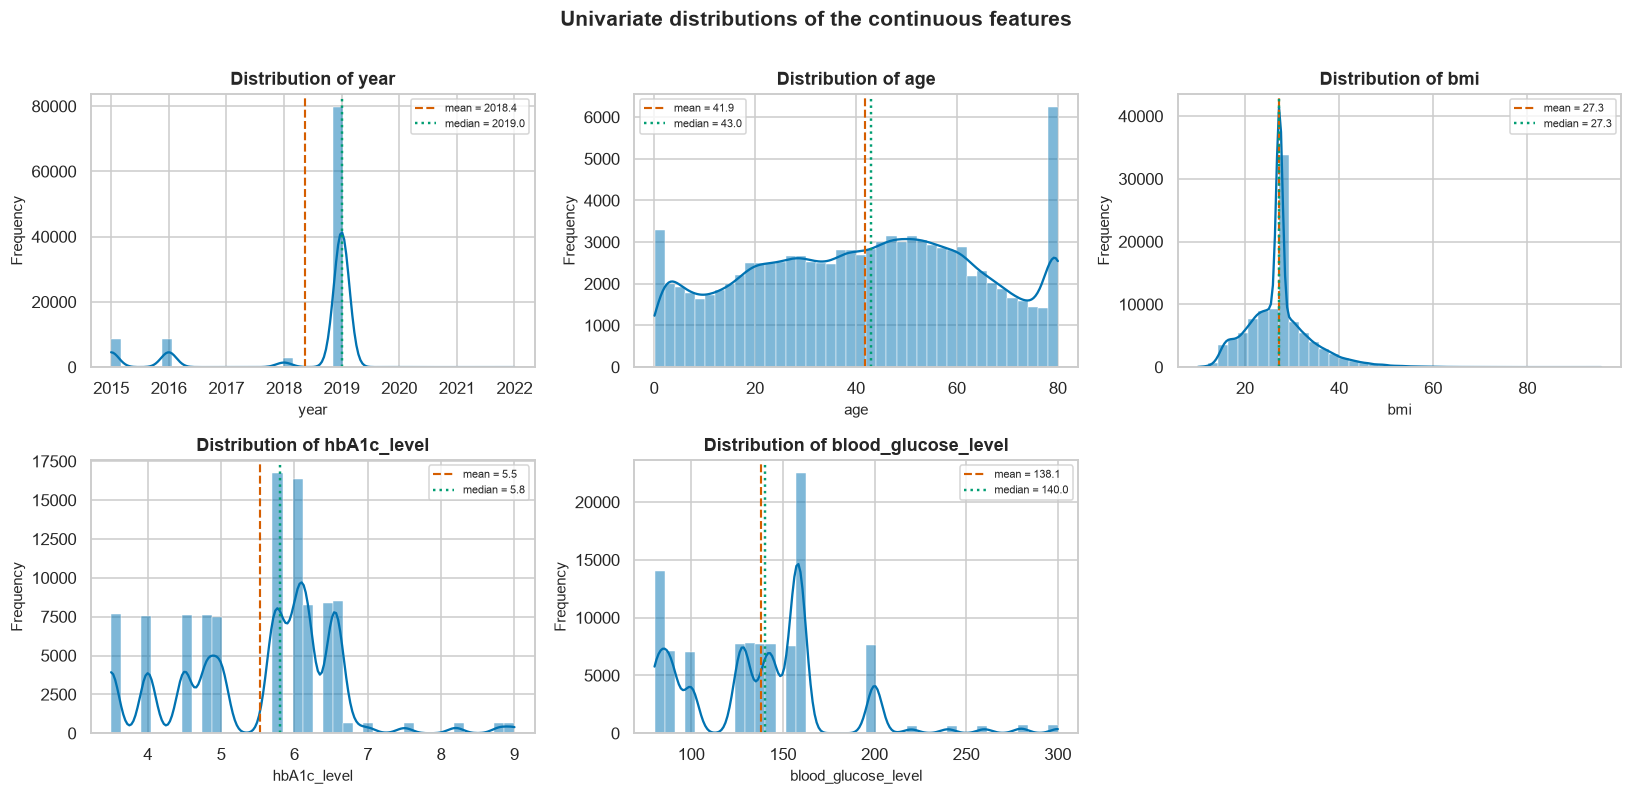

,skew,kurtosis,min,max,n_unique
year,-1.752,1.291,2015.00,2022.00,7
age,-0.052,-1.004,0.08,80.00,102
bmi,1.044,3.521,10.01,95.69,4247
hbA1c_level,-0.067,0.215,3.50,9.00,18
blood_glucose_level,0.822,1.738,80.00,300.00,18


In [6]:
numeric_cols_raw = df_raw.select_dtypes(include=np.number).columns.tolist()

# the target, the comorbidity flags and the race indicators are all 0/1 columns,
# so a histogram of them says nothing useful - exclude them from this grid
race_flag_cols = [c for c in df_raw.columns if c.startswith("race:")]
binary_flags = [TARGET, "hypertension", "heart_disease"] + race_flag_cols
continuous_cols = [c for c in numeric_cols_raw if c not in binary_flags]

print("Continuous features:", continuous_cols)
print("Binary flags excluded:", [c for c in binary_flags if c in numeric_cols_raw])

ncols = 3
nrows = int(np.ceil(len(continuous_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.0 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, col in zip(axes, continuous_cols):
    sns.histplot(data=df_raw, x=col, bins=40, kde=True, ax=ax,
                 color=sns.color_palette(PALETTE)[0], edgecolor="white", linewidth=0.3)
    ax.axvline(df_raw[col].mean(), color=sns.color_palette(PALETTE)[3],
               linestyle="--", linewidth=1.4, label=f"mean = {df_raw[col].mean():.1f}")
    ax.axvline(df_raw[col].median(), color=sns.color_palette(PALETTE)[2],
               linestyle=":", linewidth=1.6, label=f"median = {df_raw[col].median():.1f}")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7, frameon=True)

for ax in axes[len(continuous_cols):]:
    ax.set_visible(False)

fig.suptitle("Univariate distributions of the continuous features",
             fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()

# skew quantifies what the plots show: how far from symmetric each feature is
pd.DataFrame({
    "skew":     df_raw[continuous_cols].skew().round(3),
    "kurtosis": df_raw[continuous_cols].kurtosis().round(3),
    "min":      df_raw[continuous_cols].min().round(2),
    "max":      df_raw[continuous_cols].max().round(2),
    "n_unique": df_raw[continuous_cols].nunique(),
})

### Observation — 2.1

- `bmi` is right-skewed and has one value, 27.32, repeated far more than any other.
- `hbA1c_level` and `blood_glucose_level` each take only 18 distinct values, so their histograms are spiky rather than smooth.
- `age` is broadly flat across the adult range and close to symmetric.
- `year` varies over a small set of values and shows no clear shape.

## 2.2 Correlation heatmap

Pearson correlation across the numeric columns, to see which features move with
the target and whether any predictors duplicate one another.

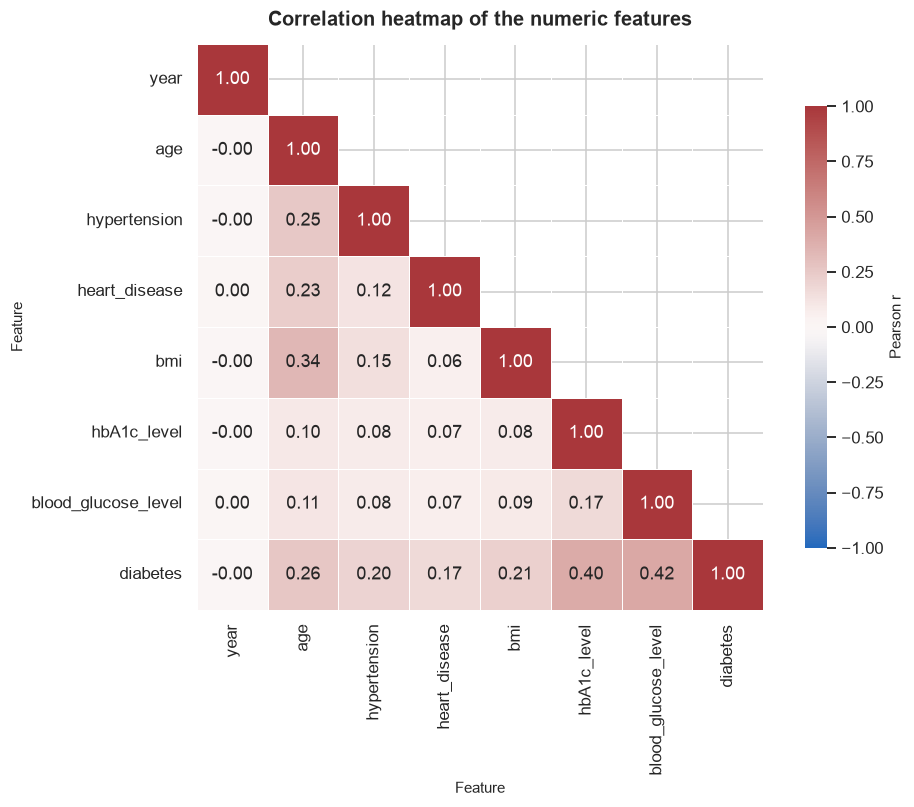

Correlation with the target, ranked by absolute value:


,r
blood_glucose_level,0.4196
hbA1c_level,0.4007
age,0.2580
bmi,0.2144
hypertension,0.1978
heart_disease,0.1717
year,-0.0035


In [7]:
corr_cols = [c for c in numeric_cols_raw if c not in race_flag_cols]
corr = df_raw[corr_cols].corr(numeric_only=True)

# mask the upper triangle so each pair is shown once
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.78, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation heatmap of the numeric features",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Correlation with the target, ranked by absolute value:")
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(4).to_frame("r")

### Observation — 2.2

- Correlation with the target: `blood_glucose_level` 0.4196, `hbA1c_level` 0.4007, `age` 0.2580, `bmi` 0.2144, `hypertension` 0.1978, `heart_disease` 0.1717.
- `year` is -0.0035, effectively zero.
- No pair of predictors is strongly correlated with any other predictor; the largest off-diagonal values are small.

## 2.3 Target class distribution

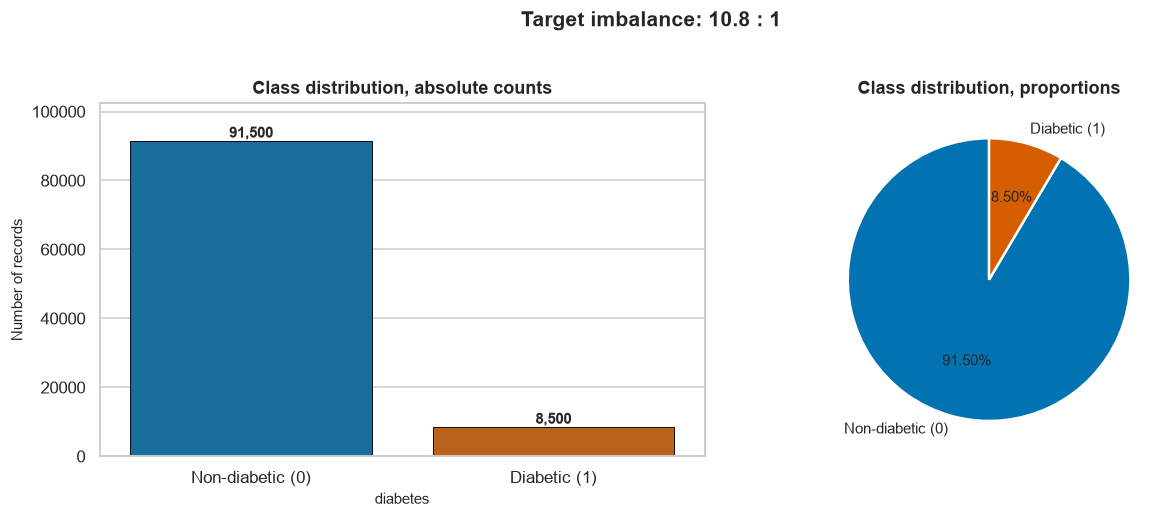

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.countplot(data=df_raw, x=TARGET, order=[0, 1], ax=axes[0],
              hue=TARGET, legend=False,
              palette=[CLASS_COLOURS[0], CLASS_COLOURS[1]],
              edgecolor="black", linewidth=0.6)
axes[0].set_title("Class distribution, absolute counts")
axes[0].set_xlabel("diabetes")
axes[0].set_ylabel("Number of records")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels([CLASS_LABELS[0], CLASS_LABELS[1]])
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylim(0, counts.max() * 1.12)

axes[1].pie(counts.values,
            labels=[CLASS_LABELS[i] for i in counts.index],
            colors=[CLASS_COLOURS[0], CLASS_COLOURS[1]],
            autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.6},
            textprops={"fontsize": 10})
axes[1].set_title("Class distribution, proportions")
axes[1].set_ylabel("")

fig.suptitle(f"Target imbalance: {imbalance_ratio:.1f} : 1",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 2.3

- 91.5% of records are non-diabetic and 8.5% are diabetic, a ratio of 10.76 to 1.
- The majority-class baseline accuracy is therefore 91.5%.
- The split in section 3 uses `stratify=y` so both partitions keep the same 8.5% rate.

## 2.4 Feature-target relationships

With 100,000 records a raw scatter is a solid block of ink, so each panel is drawn
from a reproducible 6,000-row sample with alpha blending. The sampling affects the
picture only, never the modelling.

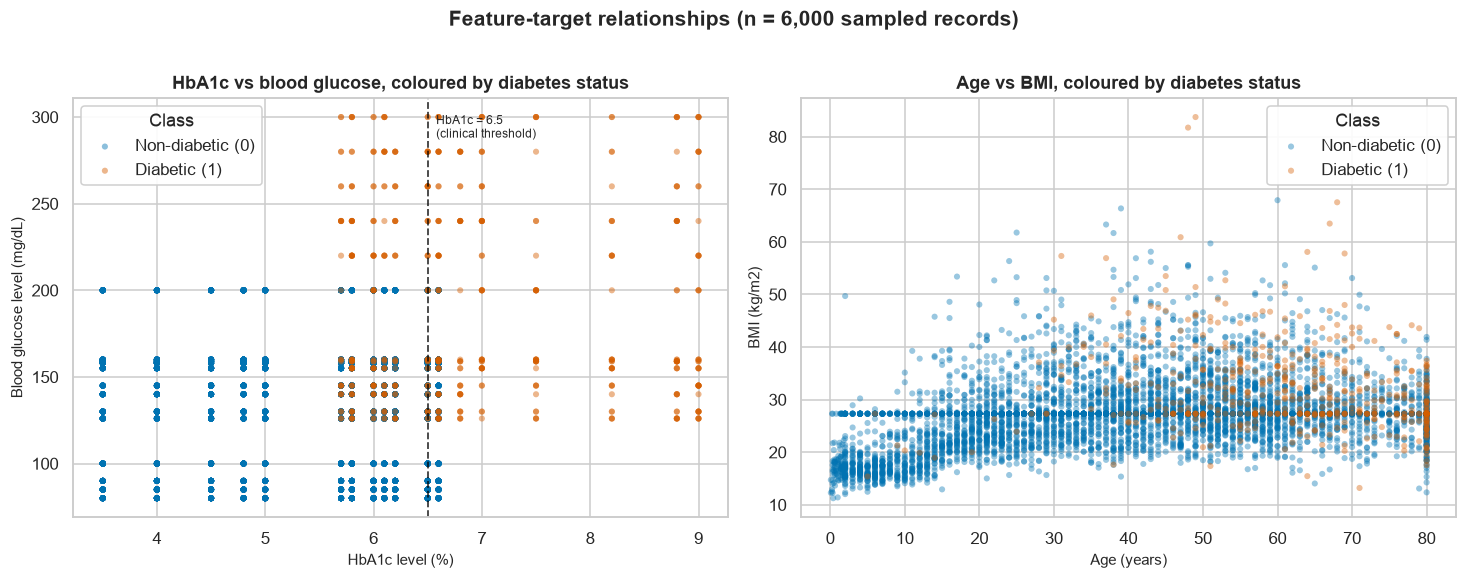

age           bmi        hbA1c_level        blood_glucose_level  \
           mean median   mean median        mean median                mean   
diabetes                                                                      
0         40.12   40.0  26.89  27.32        5.40    5.8              132.85   
1         60.95   62.0  31.99  29.97        6.93    6.6              194.09   

                 
         median  
diabetes         
0         140.0  
1         160.0

In [9]:
SCATTER_N = 6_000
df_s = df_raw.sample(n=min(SCATTER_N, len(df_raw)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

# the two diagnostic markers against each other, coloured by class
for cls in [0, 1]:
    sub = df_s[df_s[TARGET] == cls]
    axes[0].scatter(sub["hbA1c_level"], sub["blood_glucose_level"],
                    s=16, alpha=0.45, color=CLASS_COLOURS[cls],
                    label=CLASS_LABELS[cls], edgecolors="none")
axes[0].axvline(6.5, color="black", linestyle="--", linewidth=1.2, alpha=0.75)
axes[0].text(6.55, axes[0].get_ylim()[1] * 0.97, " HbA1c = 6.5\n (clinical threshold)",
             fontsize=8, va="top")
axes[0].set_title("HbA1c vs blood glucose, coloured by diabetes status")
axes[0].set_xlabel("HbA1c level (%)")
axes[0].set_ylabel("Blood glucose level (mg/dL)")
axes[0].legend(title="Class", loc="upper left", framealpha=0.92)

# the two main risk factors, for contrast
for cls in [0, 1]:
    sub = df_s[df_s[TARGET] == cls]
    axes[1].scatter(sub["age"], sub["bmi"],
                    s=16, alpha=0.40, color=CLASS_COLOURS[cls],
                    label=CLASS_LABELS[cls], edgecolors="none")
axes[1].set_title("Age vs BMI, coloured by diabetes status")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("BMI (kg/m2)")
axes[1].legend(title="Class", loc="upper right", framealpha=0.92)

fig.suptitle(f"Feature-target relationships (n = {len(df_s):,} sampled records)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# the same relationships as numbers
df_raw.groupby(TARGET)[["age", "bmi", "hbA1c_level", "blood_glucose_level"]] \
      .agg(["mean", "median"]).round(2)

### Observation — 2.4

- In the HbA1c against glucose panel, diabetic records sit almost entirely in the upper-right region.
- The boundary between the two classes runs along the axes rather than diagonally.
- In the age against BMI panel the two classes overlap heavily across the whole range.
- Group means: diabetic records average a higher HbA1c and glucose than non-diabetic records, with a smaller gap on BMI and age.

---
# 3. Preprocessing and Feature Engineering

### Order of operations

The sequence below is deliberate, and it is what keeps test data out of the
training pipeline.

| Step | Operation | Applied to | Safe because |
|------|-----------|-----------|--------------|
| 3.1 | Reconstruct `race` | full frame | deterministic reshape, learns nothing |
| 3.2 | Drop duplicates | full frame | row identity only, no statistics |
| 3.3 | Declare missing-value strategy | — | declared now, fitted later |
| 3.4 | Measure IQR outliers | full frame | reporting only, bounds refitted in 3.7 |
| 3.5 | Feature engineering | row-wise | each row uses only its own values |
| 3.6 | Train/test split | — | the split itself |
| 3.7 | Fit imputer, encoder, scaler | **train only** | `.fit()` never sees test data |

Steps 3.1, 3.2 and 3.5 happen before the split because none of them estimates a
parameter from the data. Everything that does - imputation values, category
vocabularies, IQR bounds, means and standard deviations - happens after the
split and is fitted on `X_train` alone.

## 3.1 Reconstruct the `race` column

The dataset ships `race` already one-hot encoded across five columns. Collapsing
it back to a single categorical column lets it be explored and re-encoded under
the same train-only discipline as every other categorical.

In [10]:
df = df_raw.copy()

if race_flag_cols:
    # confirm the indicators really are mutually exclusive before collapsing them
    row_sums = df[race_flag_cols].sum(axis=1)
    print("race indicator row-sums:", row_sums.value_counts().to_dict())
    assert (row_sums == 1).all(), "race indicators are not mutually exclusive"

    df["race"] = df[race_flag_cols].idxmax(axis=1).str.replace("race:", "", regex=False)
    df = df.drop(columns=race_flag_cols)
    print(f"\nCollapsed {len(race_flag_cols)} indicator columns into one 'race' column")
    print("Levels:", sorted(df["race"].unique()))

print("\nShape:", df.shape)
df.head(3)

race indicator row-sums: {1: 100000}

Collapsed 5 indicator columns into one 'race' column
Levels: ['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']

Shape: (100000, 12)


,year,gender,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,race
0,2020,Female,32.0,Alabama,0,0,never,27.32,5.0,100,0,Other
1,2015,Female,29.0,Alabama,0,0,never,19.95,5.0,90,0,Asian
2,2015,Male,18.0,Alabama,0,0,never,23.76,4.8,160,0,Other


## 3.2 Duplicate detection and removal

Exact duplicates are removed. In a clinical extract, a record identical across all
16 fields is far more likely to be an export artefact than two genuinely distinct
patients. Leaving them in also lets the same row land in both the training and
test splits, which inflates test scores.

In [11]:
n_before = len(df)
dup_mask = df.duplicated(keep="first")
n_dupes = int(dup_mask.sum())

print(f"Rows before deduplication : {n_before:,}")
print(f"Exact duplicate rows      : {n_dupes:,}  ({n_dupes / n_before * 100:.3f}%)")

if n_dupes:
    print("\nClass balance within the duplicated rows:")
    print(df.loc[dup_mask, TARGET].value_counts().to_string())

df = df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"\nRows after deduplication  : {len(df):,}  (removed {n_before - len(df):,})")
print("Target distribution after :",
      df[TARGET].value_counts(normalize=True).round(4).to_dict())

Rows before deduplication : 100,000
Exact duplicate rows      : 14  (0.014%)

Class balance within the duplicated rows:
diabetes
0    14

Rows after deduplication  : 99,986  (removed 14)
Target distribution after : {0: 0.915, 1: 0.085}


## 3.3 Missing-value strategy

**Strategy: median imputation for numeric features, most-frequent for categorical
features, both fitted on the training split only.**

Median rather than mean for the numeric columns, because section 2.1 showed `bmi`
and `blood_glucose_level` are right-skewed. The mean of a skewed distribution is
pulled toward the tail, so mean-imputation would push every imputed record upward.
The median is not affected by that.

`"No Info"` in `smoking_history` is deliberately left alone rather than imputed. It
records that the information was never collected, not that the patient never
smoked. Replacing it with the modal value would invent a behavioural claim the data
does not support, so it is kept as its own category and the models can use whatever
"not recorded" signals.

This dataset has no true nulls, so the imputers fitted in 3.7 will be no-ops. They
stay in the pipeline so it remains correct if it is ever re-run on an incomplete
extract.

In [12]:
print("Null counts per column:")
print(df.isna().sum().to_string())
print("\nTotal nulls:", int(df.isna().sum().sum()))

if "smoking_history" in df.columns:
    sh = df["smoking_history"].value_counts()
    sh_pct = df["smoking_history"].value_counts(normalize=True) * 100
    print("\n'smoking_history' levels:")
    print(pd.DataFrame({"count": sh, "percent": sh_pct.round(2)}).to_string())
    if "No Info" in sh.index:
        print(f"\n'No Info' covers {sh_pct['No Info']:.2f}% of records, "
              f"kept as its own category rather than imputed.")

Null counts per column:
year                   0
gender                 0
age                    0
location               0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
race                   0

Total nulls: 0

'smoking_history' levels:
                 count  percent
smoking_history                
No Info          35806    35.81
never            35091    35.10
former            9352     9.35
current           9286     9.29
not current       6447     6.45
ever              4004     4.00

'No Info' covers 35.81% of records, kept as its own category rather than imputed.


## 3.4 Outlier analysis, IQR method

**Method: Tukey's interquartile-range rule.** For each continuous feature, values
outside

$$[\,Q_1 - 1.5 \times IQR,\;\; Q_3 + 1.5 \times IQR\,] \qquad IQR = Q_3 - Q_1$$

are flagged.

**Treatment: winsorisation, meaning clip to the bounds, rather than deletion.** The
cell below measures the flagged rows and, crucially, what fraction of them are
diabetic - that number decides whether these are errors to remove or signal to keep.

This cell only measures. $Q_1$ and $Q_3$ are statistics estimated from data, so
computing them on the full frame and clipping now would leak the test
distribution into training. The bounds actually applied are recomputed on
`X_train` alone in section 3.7.

In [13]:
def iqr_bounds(series, k=1.5):
    '''Tukey lower and upper fences for a numeric series.'''
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


outlier_cols = [c for c in ["age", "bmi", "hbA1c_level", "blood_glucose_level"]
                if c in df.columns]

rows = []
for col in outlier_cols:
    lo, hi = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = int(mask.sum())
    rows.append({
        "feature":     col,
        "Q1":          round(df[col].quantile(0.25), 2),
        "Q3":          round(df[col].quantile(0.75), 2),
        "lower_fence": round(lo, 2),
        "upper_fence": round(hi, 2),
        "n_outliers":  n_out,
        "outlier_%":   round(n_out / len(df) * 100, 3),
        # this is the column that decides delete vs clip
        "diabetes_rate_among_outliers_%":
            round(df.loc[mask, TARGET].mean() * 100, 2) if n_out else np.nan,
    })

outlier_report = pd.DataFrame(rows)
print(f"Baseline diabetes rate in the full frame: {df[TARGET].mean() * 100:.2f}%\n")
outlier_report

Baseline diabetes rate in the full frame: 8.50%



,feature,Q1,Q3,lower_fence,upper_fence,n_outliers,outlier_%,diabetes_rate_among_outliers_%
0,age,24.00,60.00,-30.0,114.0,0,0.000,NaN
1,bmi,23.63,29.58,14.7,38.5,7086,7.087,20.86
2,hbA1c_level,4.80,6.20,2.7,8.3,1315,1.315,100.00
3,blood_glucose_level,100.00,159.00,11.5,247.5,2038,2.038,100.00


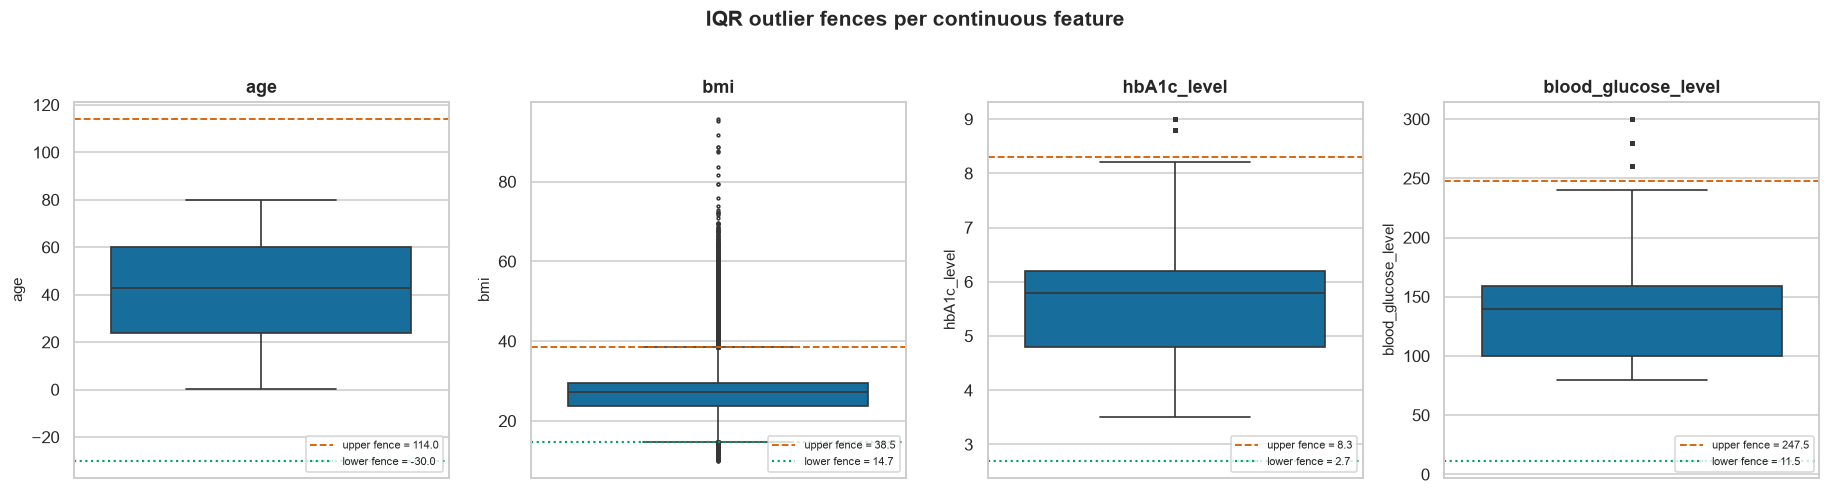

In [14]:
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4.2 * len(outlier_cols), 4.4))
axes = np.atleast_1d(axes)

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color=sns.color_palette(PALETTE)[0],
                fliersize=1.8, linewidth=1.1)
    lo, hi = iqr_bounds(df[col])
    ax.axhline(hi, color=sns.color_palette(PALETTE)[3], linestyle="--",
               linewidth=1.2, label=f"upper fence = {hi:.1f}")
    ax.axhline(lo, color=sns.color_palette(PALETTE)[2], linestyle=":",
               linewidth=1.4, label=f"lower fence = {lo:.1f}")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel(col)
    ax.legend(fontsize=7.5, loc="lower right")

fig.suptitle("IQR outlier fences per continuous feature",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 3.4

- IQR flags 1,315 outliers in `hbA1c_level` and 2,038 in `blood_glucose_level`.
- 100% of both groups are diabetic, against a baseline diabetes rate of 8.50% in the full frame.
- `bmi` has 7,086 flagged rows, 20.86% of them diabetic.
- `age` has no outliers at all; its fences fall outside the possible range of the column.
- The flagged HbA1c and glucose rows total 3,353 records, which is 39% of the 8,500 diabetic cases in the dataset.
- Treatment is winsorisation, using bounds recomputed on the training split in section 3.7.

## 3.5 Feature engineering

Three new features are added. All three are **strictly row-wise**: each is computed
from that record's own values and nothing else. No statistic is calculated across
rows, so creating them before the train/test split leaks nothing.

### Feature 1 — `bmi_category`

`bmi` binned into the standard WHO bands: Underweight (<18.5), Normal (18.5–25),
Overweight (25–30), Obese_I (30–35), Obese_II+ (>=35).

**Why it might help.** The relationship between BMI and diabetes risk is not a
straight line. Risk does not creep up evenly with every BMI point; it steps up
sharply once a patient crosses into obesity. A linear model handed raw `bmi` can
only fit one constant slope and cannot express that step. Giving it explicit bands
lets Logistic Regression and Naive Bayes use a non-linearity they otherwise cannot
represent. It also absorbs the repeated 27.32 value noted in section 2.1 into a
single band rather than leaving it as a spike.

### Feature 2 — `age_risk_interaction` = `age` × `hbA1c_level` / 100

**Why it might help.** Risk is not simply additive in age and glycaemic level. An
elevated HbA1c in a 70-year-old carries different weight from the same reading in a
25-year-old. A linear model cannot represent the product of two inputs unless that
product is supplied explicitly, so this hands it an interaction effect it could not
otherwise see. Dividing by 100 keeps the values on a similar order of magnitude to
the other features before scaling.

### Feature 3 — `metabolic_risk_score`

A count of how many clinical risk flags a patient carries: HbA1c >= 5.7 (the
pre-diabetic threshold), glucose >= 140, BMI >= 30, hypertension, and heart disease.
The score runs 0 to 5.

**Why it might help.** It compresses five individually weak signals into one ordinal
"how many risk factors does this patient have" variable. This is particularly useful
for Gaussian Naive Bayes, whose independence assumption prevents it from combining
co-occurring flags on its own.

**Why it is leakage-free.** The thresholds are fixed clinical constants taken from
the medical literature, not quantiles computed from this dataset. Nothing about the
data, and therefore nothing about the test split, influences where the cut-offs sit.

In [15]:
def engineer_features(frame):
    '''Add the three engineered features.

    Every calculation uses only values from within the same row, so this is safe
    to run before the train/test split.
    '''
    out = frame.copy()

    # WHO bands. risk steps up at obesity rather than rising smoothly per BMI point,
    # and a linear model given raw bmi can only fit one constant slope
    out["bmi_category"] = pd.cut(
        out["bmi"],
        bins=[-np.inf, 18.5, 25.0, 30.0, 35.0, np.inf],
        labels=["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II+"],
    ).astype(str)

    # a linear model cannot represent age x hbA1c unless the product is handed to it
    out["age_risk_interaction"] = (out["age"] * out["hbA1c_level"]) / 100.0

    # thresholds are fixed clinical constants from the literature, NOT quantiles
    # computed from this dataset - that is what keeps this leakage-free
    out["metabolic_risk_score"] = (
        (out["hbA1c_level"]         >= 5.7).astype(int) +
        (out["blood_glucose_level"] >= 140).astype(int) +
        (out["bmi"]                 >= 30).astype(int) +
        out["hypertension"].astype(int) +
        out["heart_disease"].astype(int)
    )
    return out


df = engineer_features(df)

print("Added: bmi_category, age_risk_interaction, metabolic_risk_score")
print("Shape:", df.shape)
df[["bmi", "bmi_category", "age", "hbA1c_level",
    "age_risk_interaction", "metabolic_risk_score"]].head()

Added: bmi_category, age_risk_interaction, metabolic_risk_score
Shape: (99986, 15)


,bmi,bmi_category,age,hbA1c_level,age_risk_interaction,metabolic_risk_score
0,27.32,Overweight,32.0,5.0,1.600,0
1,19.95,Normal,29.0,5.0,1.450,0
2,23.76,Normal,18.0,4.8,0.864,1
3,27.32,Overweight,41.0,4.0,1.640,1
4,23.75,Normal,52.0,6.5,3.380,1


### Do the new features actually separate the classes?

A feature only earns its place if the diabetes rate changes across its values. Both
tables below report prevalence per level, so the relationship can be read directly.

In [16]:
band_order = ["Underweight", "Normal", "Overweight", "Obese_I", "Obese_II+"]
band_order = [b for b in band_order if b in df["bmi_category"].unique()]

bmi_tab = (df.groupby("bmi_category")
             .agg(n_records=(TARGET, "size"),
                  diabetes_rate_pct=(TARGET, lambda s: round(s.mean() * 100, 2)))
             .reindex(band_order))
print("Diabetes rate by bmi_category:")
print(bmi_tab.to_string())

risk_tab = df.groupby("metabolic_risk_score").agg(
    n_records=(TARGET, "size"),
    diabetes_rate_pct=(TARGET, lambda s: round(s.mean() * 100, 2)),
)
print("\nDiabetes rate by metabolic_risk_score:")
print(risk_tab.to_string())

# how does the interaction term compare with its two parent columns?
print("\nCorrelation with the target:")
for col in ["age", "hbA1c_level", "age_risk_interaction", "metabolic_risk_score"]:
    print(f"  {col:<22} {df[col].corr(df[TARGET]):+.4f}")

Diabetes rate by bmi_category:
              n_records  diabetes_rate_pct
bmi_category                              
Underweight        8521               0.75
Normal            22291               3.89
Overweight        45691               7.30
Obese_I           12717              14.52
Obese_II+         10766              22.16

Diabetes rate by metabolic_risk_score:
                      n_records  diabetes_rate_pct
metabolic_risk_score                              
0                         12847               0.00
1                         37754               1.14
2                         35262               8.61
3                         11524              30.48
4                          2393              57.54
5                           206              68.93

Correlation with the target:
  age                    +0.2580
  hbA1c_level            +0.4007
  age_risk_interaction   +0.4106
  metabolic_risk_score   +0.3851


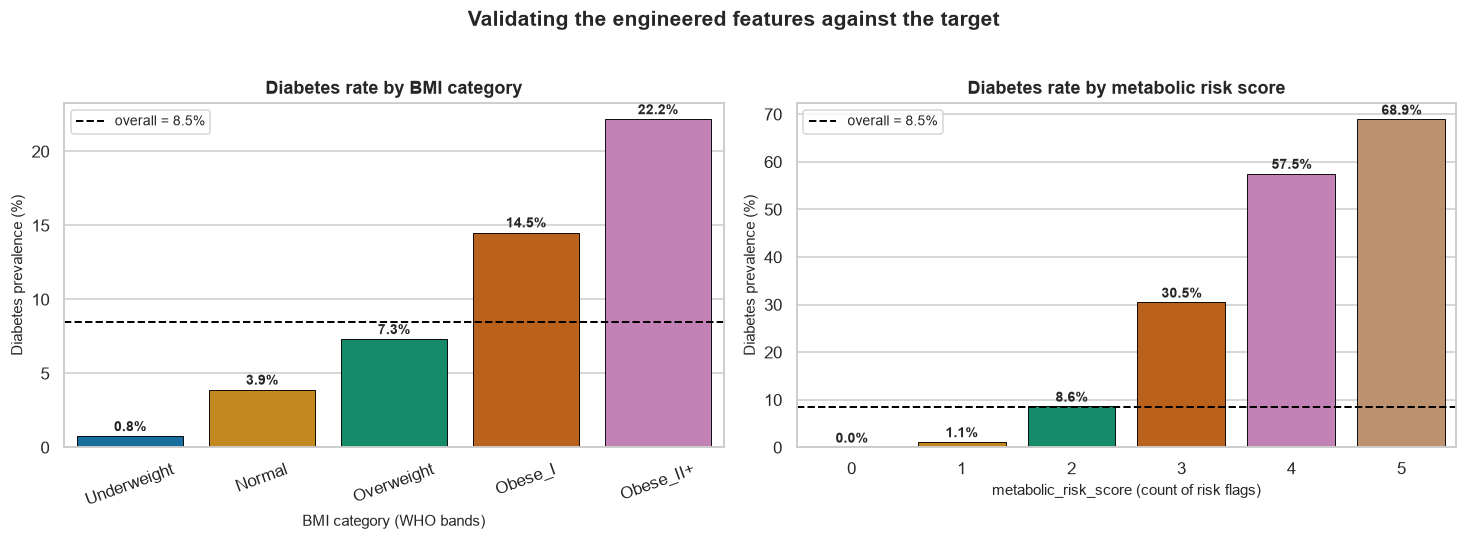

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

rate_bmi = df.groupby("bmi_category")[TARGET].mean().reindex(band_order) * 100
sns.barplot(x=rate_bmi.index, y=rate_bmi.values, ax=axes[0],
            hue=rate_bmi.index, legend=False,
            palette=PALETTE, edgecolor="black", linewidth=0.6)
axes[0].axhline(df[TARGET].mean() * 100, color="black", linestyle="--",
                linewidth=1.3, label=f"overall = {df[TARGET].mean()*100:.1f}%")
axes[0].set_title("Diabetes rate by BMI category")
axes[0].set_xlabel("BMI category (WHO bands)")
axes[0].set_ylabel("Diabetes prevalence (%)")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(rate_bmi.values):
    axes[0].text(i, v + 0.35, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

rate_risk = df.groupby("metabolic_risk_score")[TARGET].mean() * 100
sns.barplot(x=rate_risk.index.astype(str), y=rate_risk.values, ax=axes[1],
            hue=rate_risk.index.astype(str), legend=False,
            palette=PALETTE, edgecolor="black", linewidth=0.6)
axes[1].axhline(df[TARGET].mean() * 100, color="black", linestyle="--",
                linewidth=1.3, label=f"overall = {df[TARGET].mean()*100:.1f}%")
axes[1].set_title("Diabetes rate by metabolic risk score")
axes[1].set_xlabel("metabolic_risk_score (count of risk flags)")
axes[1].set_ylabel("Diabetes prevalence (%)")
axes[1].legend(fontsize=9)
for i, v in enumerate(rate_risk.values):
    axes[1].text(i, v + 1.0, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

fig.suptitle("Validating the engineered features against the target",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Observation — 3.5

- Diabetes prevalence by `bmi_category` runs 0.75%, 3.89%, 7.30%, 14.52%, 22.16% across the five WHO bands.
- Prevalence by `metabolic_risk_score` runs 0.00%, 1.14%, 8.61%, 30.48%, 57.54%, 68.93% for scores 0 through 5.
- Both sequences increase at every step, and the size of the steps grows rather than staying constant.
- Correlation with the target: `age_risk_interaction` +0.4106, `hbA1c_level` +0.4007, `metabolic_risk_score` +0.3851, `age` +0.2580.
- `age_risk_interaction` correlates more strongly with the target than either of the two columns it is built from.

## 3.6 Train/test split

The split happens now, before any transformer is fitted. Everything after this
point that estimates a parameter sees `X_train` only.

`stratify=y` forces both partitions to keep the same 8.5% diabetic rate. Without
it, an 8.5% minority class can drift by a full percentage point purely by chance,
which makes the metric comparison between models unreliable.

In [18]:
from sklearn.model_selection import train_test_split

FEATURES_TO_DROP = [TARGET]
if "year" in df.columns:
    # section 2.2 showed r = -0.0035 with the target and no relationship with any
    # predictor, so it adds a dimension without adding information
    FEATURES_TO_DROP.append("year")
    print("Dropping 'year': administrative field, no predictive signal")

X = df.drop(columns=FEATURES_TO_DROP)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,               # keeps the 8.5% minority rate in both halves
    random_state=RANDOM_STATE,
)

print(f"\nX_train : {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"X_test  : {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")

# proof that stratification worked
split_check = pd.DataFrame({
    "full_%":  (y.value_counts(normalize=True).sort_index() * 100).round(3),
    "train_%": (y_train.value_counts(normalize=True).sort_index() * 100).round(3),
    "test_%":  (y_test.value_counts(normalize=True).sort_index() * 100).round(3),
    "train_n": y_train.value_counts().sort_index(),
    "test_n":  y_test.value_counts().sort_index(),
})
print("\nClass proportions are preserved across both splits:")
print(split_check.to_string())

Dropping 'year': administrative field, no predictive signal

X_train : 79,988 rows x 13 columns
X_test  : 19,998 rows x 13 columns

Class proportions are preserved across both splits:
          full_%  train_%  test_%  train_n  test_n
diabetes                                          
0         91.499   91.499  91.499    73188   18298
1          8.501    8.501   8.501     6800    1700


## 3.7 Preprocessing, fitted on the training split only

This is the cell where leakage would happen if the discipline slipped, so every
fitted object is created explicitly and each `.fit()` call is visibly restricted to
the training data.

### Encoding

| Column | Encoding | Reason |
|--------|----------|--------|
| `gender`, `smoking_history`, `race`, `bmi_category` | One-hot | Low cardinality, nominal, no natural ordering |
| `location` | **Frequency** | See below |

**Why `location` is frequency-encoded rather than one-hot.** It has 54 levels. One-hot
would grow the design matrix from roughly 24 columns to roughly 75, and every added
column would be sparse and carry almost no class-rate variation. That hurts this
particular model set in two concrete ways: **KNN** measures Euclidean distance, and
54 near-orthogonal sparse dimensions dilute the informative distance contributed by
HbA1c and glucose; **SVC** cost grows with dimensionality. Frequency encoding maps
each state to how often it appears **in the training split**, giving one dense
numeric column instead.

**Target encoding was rejected.** It replaces each category with the mean target
value for that category, which uses the label to build the feature. That is a
classic leakage route.

### Scaling

`StandardScaler` rescales each column to mean 0 and standard deviation 1. KNN and
SVC need this: without it `blood_glucose_level`, which runs 80 to 300, would
overwhelm `hbA1c_level`, which runs 3 to 9, purely because of the units they happen
to be measured in. Decision trees are unaffected either way since they split on
thresholds, but everything is scaled for consistency.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# declare which columns get which treatment
onehot_cols = [c for c in ["gender", "smoking_history", "race", "bmi_category"]
               if c in X_train.columns]
freq_cols = [c for c in ["location"] if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in onehot_cols + freq_cols]

print("One-hot   :", onehot_cols)
print("Frequency :", freq_cols)
print("Numeric   :", numeric_cols)

Xtr = X_train.copy()
Xte = X_test.copy()

# ---- step 1: imputation -------------------------------------------------
# median for numeric because bmi and glucose are right-skewed and the mean
# would be dragged toward the tail
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

# fit_transform on TRAIN, transform on TEST. fitting on the full frame would let
# test rows influence the imputation values, which is leakage
Xtr[numeric_cols] = num_imputer.fit_transform(Xtr[numeric_cols])
Xte[numeric_cols] = num_imputer.transform(Xte[numeric_cols])

cat_all = onehot_cols + freq_cols
if cat_all:
    Xtr[cat_all] = cat_imputer.fit_transform(Xtr[cat_all])
    Xte[cat_all] = cat_imputer.transform(Xte[cat_all])

print(f"\n[1] Imputers fitted on {len(Xtr):,} training rows only")

One-hot   : ['gender', 'smoking_history', 'race', 'bmi_category']
Frequency : ['location']
Numeric   : ['age', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'age_risk_interaction', 'metabolic_risk_score']

[1] Imputers fitted on 79,988 training rows only


In [20]:
# ---- step 2: outlier winsorisation --------------------------------------
# bounds recomputed here from TRAIN only. Q1 and Q3 are statistics, so deriving
# them from the full frame would leak the test distribution
winsor_cols = [c for c in ["bmi", "hbA1c_level", "blood_glucose_level"]
               if c in numeric_cols]
train_bounds = {}

for col in winsor_cols:
    lo, hi = iqr_bounds(Xtr[col])
    train_bounds[col] = (lo, hi)
    n_tr = int(((Xtr[col] < lo) | (Xtr[col] > hi)).sum())
    n_te = int(((Xte[col] < lo) | (Xte[col] > hi)).sum())
    # clip, do not delete: section 3.4 showed these rows are 100% diabetic
    Xtr[col] = Xtr[col].clip(lo, hi)
    Xte[col] = Xte[col].clip(lo, hi)
    print(f"[2] {col:<22} bounds=({lo:.2f}, {hi:.2f})  clipped: {n_tr:,} train / {n_te:,} test")

[2] bmi                    bounds=(14.72, 38.53)  clipped: 5,697 train / 1,383 test
[2] hbA1c_level            bounds=(2.70, 8.30)  clipped: 1,039 train / 276 test
[2] blood_glucose_level    bounds=(11.50, 247.50)  clipped: 1,632 train / 406 test


In [21]:
# ---- step 3: frequency encoding for location ----------------------------
for col in freq_cols:
    # the map is built from TRAIN frequencies only
    freq_map = Xtr[col].value_counts(normalize=True)
    Xtr[col + "_freq"] = Xtr[col].map(freq_map).astype(float)
    # a state appearing only in the test split has no training frequency -> 0.0
    Xte[col + "_freq"] = Xte[col].map(freq_map).fillna(0.0).astype(float)
    unseen = int(Xte[col + "_freq"].eq(0.0).sum())
    print(f"[3] {col}: {len(freq_map)} levels learned from train, "
          f"{unseen} test rows had an unseen level")
    Xtr = Xtr.drop(columns=[col])
    Xte = Xte.drop(columns=[col])

numeric_cols = numeric_cols + [c + "_freq" for c in freq_cols]

# ---- step 4: one-hot encoding -------------------------------------------
# handle_unknown='ignore' so a category appearing only in test degrades quietly
# instead of crashing; drop='first' avoids the dummy variable trap
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="first")
ohe_train = ohe.fit_transform(Xtr[onehot_cols])
ohe_test = ohe.transform(Xte[onehot_cols])
ohe_names = list(ohe.get_feature_names_out(onehot_cols))

print(f"\n[4] OneHotEncoder fitted on train -> {len(ohe_names)} indicator columns")

[3] location: 55 levels learned from train, 0 test rows had an unseen level

[4] OneHotEncoder fitted on train -> 15 indicator columns


In [22]:
# ---- step 5: standardisation --------------------------------------------
# mean and std come from TRAIN only, then the SAME numbers transform both halves
scaler = StandardScaler()
num_train = scaler.fit_transform(Xtr[numeric_cols])
num_test = scaler.transform(Xte[numeric_cols])

print("[5] StandardScaler fitted on train only. Learned statistics:")
print(pd.DataFrame({
    "feature":    numeric_cols,
    "train_mean": np.round(scaler.mean_, 3),
    "train_std":  np.round(np.sqrt(scaler.var_), 3),
}).to_string(index=False))

# ---- step 6: assemble the final matrices --------------------------------
feature_names = numeric_cols + ohe_names
X_train_proc = pd.DataFrame(np.hstack([num_train, ohe_train]),
                            columns=feature_names, index=Xtr.index)
X_test_proc = pd.DataFrame(np.hstack([num_test, ohe_test]),
                           columns=feature_names, index=Xte.index)

print(f"\n[6] X_train_proc : {X_train_proc.shape}")
print(f"    X_test_proc  : {X_test_proc.shape}")

[5] StandardScaler fitted on train only. Learned statistics:
             feature  train_mean  train_std
                 age      41.844     22.483
        hypertension       0.074      0.262
       heart_disease       0.039      0.193
                 bmi      27.006      5.674
         hbA1c_level       5.521      1.048
 blood_glucose_level     137.458     38.460
age_risk_interaction       2.337      1.399
metabolic_risk_score       1.535      0.950
       location_freq       0.019      0.003

[6] X_train_proc : (79988, 24)
    X_test_proc  : (19998, 24)


### Verifying that no leakage occurred

If the scaler had been fitted on the full dataset, the **test** columns would also
come out centred at exactly 0 with standard deviation exactly 1. Because it was
fitted on training data only, the training columns are exactly standardised while
the test columns deviate slightly. **That small deviation is the positive evidence
that the discipline held.**

In [23]:
check = pd.DataFrame({
    "train_mean": X_train_proc[numeric_cols].mean().round(6),
    "train_std":  X_train_proc[numeric_cols].std(ddof=0).round(6),
    "test_mean":  X_test_proc[numeric_cols].mean().round(6),
    "test_std":   X_test_proc[numeric_cols].std(ddof=0).round(6),
})
print(check.to_string())

# if this fails the scaler was never fitted on train, and every metric is suspect
assert np.allclose(X_train_proc[numeric_cols].mean(), 0, atol=1e-9), \
    "train means are not zero - scaler was not fitted on train"

# test means being exactly zero would mean the scaler saw test rows. the slight
# deviation is the positive evidence that it did not
assert not np.allclose(X_test_proc[numeric_cols].mean(), 0, atol=1e-9), \
    "test means are exactly zero - scaler appears to have been fitted on test data"

assert X_train_proc.isna().sum().sum() == 0, "NaNs in processed train matrix"
assert X_test_proc.isna().sum().sum() == 0, "NaNs in processed test matrix"
assert list(X_train_proc.columns) == list(X_test_proc.columns), "column mismatch"

print("\nAll leakage and integrity assertions passed.")

                      train_mean  train_std  test_mean  test_std
age                         -0.0        1.0   0.009307  1.007424
hypertension                -0.0        1.0   0.008799  1.014132
heart_disease               -0.0        1.0   0.013437  1.031456
bmi                          0.0        1.0  -0.011238  0.999537
hbA1c_level                 -0.0        1.0  -0.004833  0.999551
blood_glucose_level         -0.0        1.0  -0.008899  1.006024
age_risk_interaction        -0.0        1.0   0.009168  1.007402
metabolic_risk_score        -0.0        1.0  -0.003924  1.006391
location_freq                0.0        1.0  -0.015575  1.017347

All leakage and integrity assertions passed.


### Observation — 3.7

- The split gives 79,988 training rows and 19,998 test rows, both holding 8.501% diabetic.
- Training columns come out with mean 0 and standard deviation 1 to within 1e-9.
- Test columns do not; their means sit slightly away from zero.
- The assertion fails if the test means are exactly zero, which would indicate the scaler had been fitted on all the data.
- The final design matrix has 24 columns. One-hot encoding `location` instead would have produced roughly 75.